In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../datasets/housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.shape

(5000, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [5]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [6]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700,9.975771e+05
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690,1.232669e+06
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


In [9]:
df = df.drop('Address', axis=1)
X = df.drop('Price', axis=1).values
Y = df['Price'].values

In [10]:
print('Feature shape:', X.shape)
print('Target shape:', Y.shape)

Feature shape: (5000, 5)
Target shape: (5000,)


In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print('Train set:', X_train.shape, Y_train.shape)
print('Test set:', X_test.shape, Y_test.shape)

Train set: (4000, 5) (4000,)
Test set: (1000, 5) (1000,)


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
class Linear_Regression():
    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    def fit(self, X, Y):
        self.m, self.n = X.shape
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        for i in range(self.no_of_iterations):
            self.update_weights()

    def update_weights(self):
        Y_prediction = self.predict(self.X)
        dw = -(2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m
        db = -2 * np.sum(self.Y - Y_prediction) / self.m
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    def predict(self, X):
        return X.dot(self.w) + self.b

    def r2_score(self, X, Y):
        Y_pred = self.predict(X)
        ss_res = np.sum((Y - Y_pred) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        return 1 - (ss_res / ss_tot)

    def mse(self, X, Y):
        Y_pred = self.predict(X)
        return np.mean((Y - Y_pred) ** 2)


In [14]:
model = Linear_Regression(learning_rate=0.01, no_of_iterations=1000)
model.fit(X_train, Y_train)

In [15]:
print('Weights:', model.w)
print('Bias:', model.b)

Weights: [230936.30406483 164179.47085352 120745.47521526   2835.98355247
 151807.5206789 ]
Bias: 1231895.6973219335


In [16]:
train_r2 = model.r2_score(X_train, Y_train)
test_r2 = model.r2_score(X_test, Y_test)
train_mse = model.mse(X_train, Y_train)
test_mse = model.mse(X_test, Y_test)

print(f'Train R² Score: {train_r2:.4f}')
print(f'Test  R² Score: {test_r2:.4f}')
print(f'Train MSE:      {train_mse:.2f}')
print(f'Test  MSE:      {test_mse:.2f}')

Train R² Score: 0.9178
Test  R² Score: 0.9187
Train MSE:      10333293714.16
Test  MSE:      9776015967.35


### Actual vs Predicted Plot

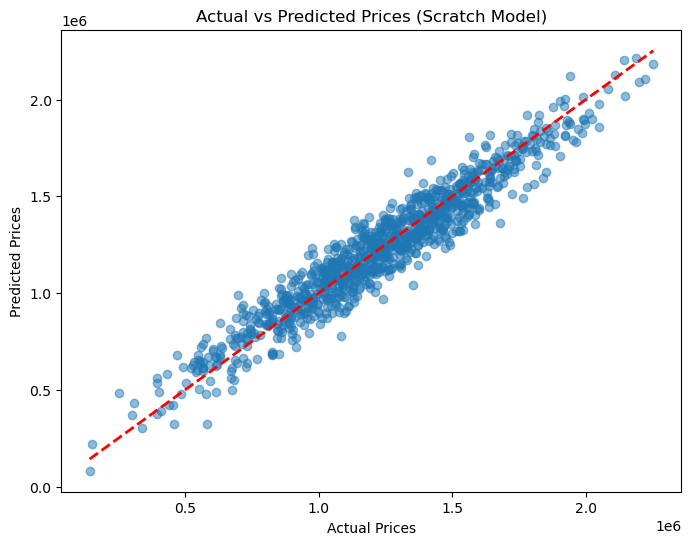

In [17]:
Y_test_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_test_pred, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Scratch Model)')
plt.show()

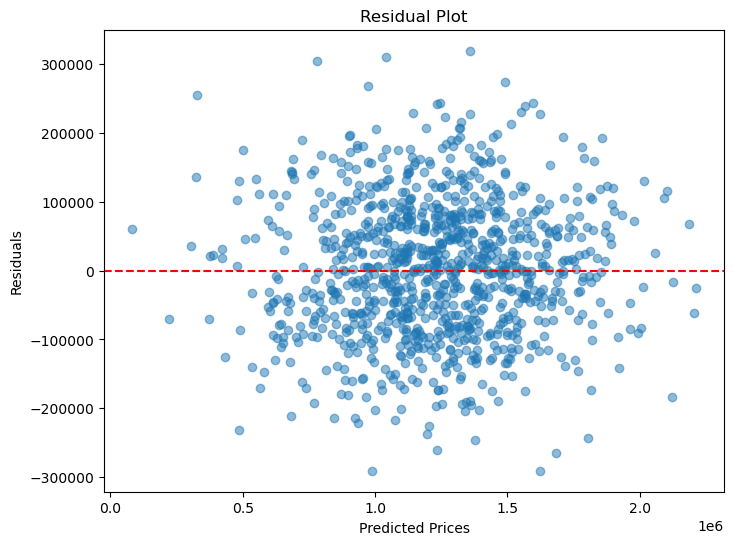

In [18]:
plt.figure(figsize=(8, 6))
residuals = Y_test - Y_test_pred
plt.scatter(Y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### Comparison with Scikit-Learn LinearRegression

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

sk_model = LinearRegression()
sk_model.fit(X_train, Y_train)

sk_pred = sk_model.predict(X_test)
sk_r2 = r2_score(Y_test, sk_pred)
sk_mse = mean_squared_error(Y_test, sk_pred)

print(f'Sklearn R² Score: {sk_r2:.4f}')
print(f'Sklearn MSE:      {sk_mse:.2f}')
print(f'\nSklearn Coefficients:', sk_model.coef_)
print(f'Sklearn Intercept:     {sk_model.intercept_:.2f}')

Sklearn R² Score: 0.9187
Sklearn MSE:      9776004984.83

Sklearn Coefficients: [230936.34868847 164179.51022496 120746.66171718   2834.7953367
 151807.44000457]
Sklearn Intercept:     1231895.70


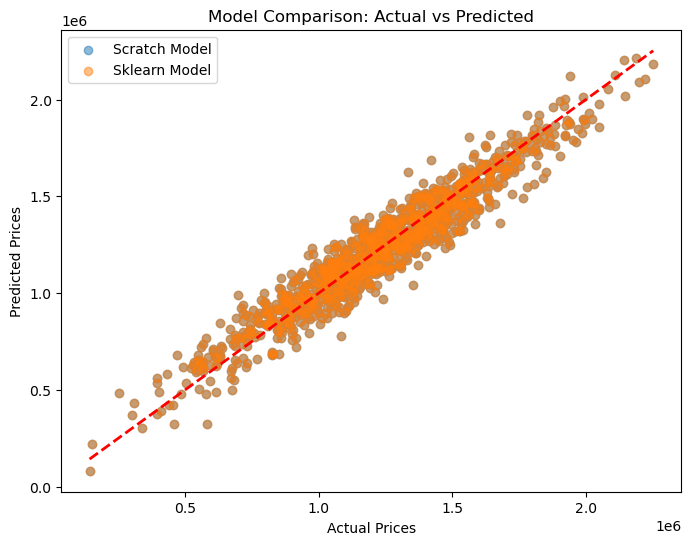

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_test_pred, alpha=0.5, label='Scratch Model')
plt.scatter(Y_test, sk_pred, alpha=0.5, label='Sklearn Model')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Model Comparison: Actual vs Predicted')
plt.legend()
plt.show()